In [1]:
!pip install roboflow --no-deps
!pip install filetype opencv-python-headless idna pi-heif
!pip install pillow-avif-plugin==1.5.2
# albumentations is used in the dataset pipeline but is not guaranteed on the
# Colab base image — install it explicitly for reproducibility.
!pip install -q albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 42.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
roboflow 1.3.13 requires pillow-avif-plugin<2, which is not installed.
roboflow 1.3.13 requires opencv-python-headless==4.10.0.84, but you have opencv-python-headless 4.13.0.92 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 77.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
roboflow 1.3.13 requires opencv-python-headless==4.10.0.84, but you have opencv-python-headless 4.13.0.92 which is incompatible.


In [3]:
import os
from roboflow import Roboflow
from google.colab import userdata

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')

ROBOFLOW_PROJECT_ID = 'erotica-detection'
ROBOFLOW_VERSION_NUMBER = 4

# Initialize Roboflow
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# Get project and dataset version
project = rf.workspace('renaire-odarve').project(ROBOFLOW_PROJECT_ID)
dataset = project.version(ROBOFLOW_VERSION_NUMBER)
dataset.download("yolov5pytorch", location="./erotica-detection-yolov5")

print("Roboflow dataset downloaded successfully to ./erotica-detection-yolov5")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to ./erotica-detection-yolov5 in yolov5pytorch:: 100%|██████████| 31628/31628 [00:03<00:00, 8872.59it/s] 


Roboflow dataset downloaded successfully to ./erotica-detection-yolov5


In [4]:
import os
import yaml
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision
from PIL import Image
import numpy as np
from pathlib import Path
import cv2
from tqdm import tqdm
import json
from collections import defaultdict
import torchvision.models as models
import math
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [5]:
class YOLODataset(Dataset):
    def __init__(self, yaml_path, split='train', img_size=512, cache_images=False):
        with open(yaml_path, 'r') as f:
            self.config = yaml.safe_load(f)

        self.img_size = img_size
        self.split = split
        self.cache_images = cache_images
        self.imgs = None

        # Resolve image directory
        yaml_dir = Path(yaml_path).parent
        path_entry = self.config.get(split)
        if not path_entry:
            raise ValueError(f"Split '{split}' not found in {yaml_path}")

        possible_path = yaml_dir / path_entry
        if possible_path.exists():
            self.img_dir = possible_path
        else:
            self.img_dir = Path(path_entry)

        self.img_files = sorted(list(self.img_dir.glob('*.jpg')) +
                                list(self.img_dir.glob('*.png')) +
                                list(self.img_dir.glob('*.jpeg')))

        # Initialize cache
        if self.cache_images:
            self.imgs = [None] * len(self.img_files)

        self.num_classes = self.config.get('nc', 80)
        self.class_names = self.config.get('names', [])

        # Define Albumentations Transforms
        if split == 'train':
            self.transform = A.Compose([
                A.Resize(height=img_size, width=img_size),
                A.HorizontalFlip(p=0.5),
                A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5, border_mode=cv2.BORDER_CONSTANT),
                A.RandomBrightnessContrast(p=0.5),
                A.HueSaturationValue(p=0.3),
                A.GaussNoise(p=0.2),
                A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
                ToTensorV2()
            ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.4))
        else:
            self.transform = A.Compose([
                A.Resize(height=img_size, width=img_size),
                A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
                ToTensorV2()
            ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        # Check Cache
        if self.cache_images and self.imgs[idx] is not None:
            image = self.imgs[idx]
            img_path = self.img_files[idx] # Still need path for labels/debugging
        else:
            img_path = self.img_files[idx]
            # Load Image with OpenCV (BGR -> RGB)
            image = cv2.imread(str(img_path))
            if image is None:
                print(f"Warning: Could not load image {img_path}")
                image = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
            else:
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            # Save to cache
            if self.cache_images:
                self.imgs[idx] = image

        # Determine Label Path
        path_str = str(img_path)
        if 'images' in path_str:
            label_path = Path(path_str.replace('images', 'labels').rsplit('.', 1)[0] + '.txt')
        else:
            label_path = img_path.with_suffix('.txt')

        bboxes = []
        labels = []

        if label_path.exists():
            with open(label_path, 'r') as f:
                lines = f.readlines()

            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    try:
                        cls = int(float(parts[0]))
                        x_c = float(parts[1])
                        y_c = float(parts[2])
                        w = float(parts[3])
                        h = float(parts[4])

                        # Ensure normalized coordinates are valid for albumentations
                        x_c = max(0.0, min(1.0, x_c))
                        y_c = max(0.0, min(1.0, y_c))
                        w = max(0.0, min(1.0, w))
                        h = max(0.0, min(1.0, h))

                        bboxes.append([x_c, y_c, w, h])
                        labels.append(cls)
                    except ValueError:
                        continue

        # Apply Albumentations
        try:
            transformed = self.transform(image=image, bboxes=bboxes, class_labels=labels)
            img_tensor = transformed['image']
            trans_bboxes = transformed['bboxes']
            trans_labels = transformed['class_labels']
        except Exception as e:
            print(f"Augmentation Error on {img_path}: {e}")
            img_tensor = transforms.ToTensor()(Image.fromarray(image))
            trans_bboxes = []
            trans_labels = []

        # Convert normalized YOLO format back to absolute (x1, y1, x2, y2) for the model
        final_boxes = []
        final_labels = []

        for box, label in zip(trans_bboxes, trans_labels):
            x_c, y_c, w, h = box

            # Convert to absolute xyxy
            x1 = (x_c - w / 2) * self.img_size
            y1 = (y_c - h / 2) * self.img_size
            x2 = (x_c + w / 2) * self.img_size
            y2 = (y_c + h / 2) * self.img_size

            # Clamp
            x1 = max(0, min(x1, self.img_size))
            y1 = max(0, min(y1, self.img_size))
            x2 = max(0, min(x2, self.img_size))
            y2 = max(0, min(y2, self.img_size))

            if x2 > x1 and y2 > y1:
                final_boxes.append([x1, y1, x2, y2])
                final_labels.append(label)

        if len(final_boxes) > 0:
            target_boxes = torch.tensor(final_boxes, dtype=torch.float32)
            target_labels = torch.tensor(final_labels, dtype=torch.int64)
        else:
            target_boxes = torch.zeros((0, 4), dtype=torch.float32)
            target_labels = torch.zeros((0,), dtype=torch.int64)

        target = {'boxes': target_boxes, 'labels': target_labels}
        return img_tensor, target

In [6]:
# --- Model Components & Utilities ---
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import torchvision
import torchvision.models as models

# 1. Box Utilities
def box_iou(boxes1, boxes2):
    """Compute IoU between two sets of boxes."""
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])
    lt = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    rb = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    wh = (rb - lt).clamp(min=0)
    inter = wh[:, :, 0] * wh[:, :, 1]
    union = area1[:, None] + area2 - inter
    return inter / (union + 1e-6)

def encode_boxes(boxes, anchors):
    """Encode target boxes relative to anchors."""
    anchor_widths = anchors[:, 2] - anchors[:, 0]
    anchor_heights = anchors[:, 3] - anchors[:, 1]
    anchor_ctr_x = anchors[:, 0] + 0.5 * anchor_widths
    anchor_ctr_y = anchors[:, 1] + 0.5 * anchor_heights
    box_widths = boxes[:, 2] - boxes[:, 0]
    box_heights = boxes[:, 3] - boxes[:, 1]
    box_ctr_x = boxes[:, 0] + 0.5 * box_widths
    box_ctr_y = boxes[:, 1] + 0.5 * box_heights
    dx = (box_ctr_x - anchor_ctr_x) / anchor_widths
    dy = (box_ctr_y - anchor_ctr_y) / anchor_heights
    dw = torch.log(box_widths / anchor_widths + 1e-8)
    dh = torch.log(box_heights / anchor_heights + 1e-8)
    return torch.stack([dx, dy, dw, dh], dim=1)

def decode_boxes(box_preds, anchors, img_size=None):
    """Decode predicted boxes from anchor offsets with optional clipping."""
    anchor_widths = anchors[:, 2] - anchors[:, 0]
    anchor_heights = anchors[:, 3] - anchors[:, 1]
    anchor_ctr_x = anchors[:, 0] + 0.5 * anchor_widths
    anchor_ctr_y = anchors[:, 1] + 0.5 * anchor_heights
    dx, dy, dw, dh = box_preds[:, 0], box_preds[:, 1], box_preds[:, 2], box_preds[:, 3]
    pred_ctr_x = dx * anchor_widths + anchor_ctr_x
    pred_ctr_y = dy * anchor_heights + anchor_ctr_y
    pred_w = torch.exp(dw) * anchor_widths
    pred_h = torch.exp(dh) * anchor_heights
    x1 = pred_ctr_x - 0.5 * pred_w
    y1 = pred_ctr_y - 0.5 * pred_h
    x2 = pred_ctr_x + 0.5 * pred_w
    y2 = pred_ctr_y + 0.5 * pred_h

    if img_size is not None:
        # Support both int (square) and tuple (h, w)
        if isinstance(img_size, (int, float)):
            h = w = float(img_size)
        else:
            h, w = float(img_size[0]), float(img_size[1])
        x1 = x1.clamp(min=0, max=w)
        y1 = y1.clamp(min=0, max=h)
        x2 = x2.clamp(min=0, max=w)
        y2 = y2.clamp(min=0, max=h)

    return torch.stack([x1, y1, x2, y2], dim=1)

def multiclass_nms(boxes, scores, labels, iou_threshold=0.5, score_threshold=0.05):
    """Multi-class NMS using torchvision batched_nms."""
    # 1. Global Confidence Thresholding
    keep_mask = scores > score_threshold
    boxes = boxes[keep_mask]
    scores = scores[keep_mask]
    labels = labels[keep_mask]

    if boxes.numel() == 0:
        return torch.zeros((0, 4), device=boxes.device), torch.zeros(0, device=boxes.device), torch.zeros(0, dtype=torch.long, device=labels.device)

    # 2. Batched NMS (Fast)
    keep_indices = torchvision.ops.batched_nms(boxes, scores, labels, iou_threshold)

    return boxes[keep_indices], scores[keep_indices], labels[keep_indices]

# 2. Model Architecture

# EfficientDet Compound Scaling Configurations (phi 0-7)
EFFICIENTDET_CONFIGS = {
    0: {'backbone': 'efficientnet_b0', 'fpn_channels': 64,  'num_bifpn': 3, 'num_head_layers': 3, 'img_size': 512},
    1: {'backbone': 'efficientnet_b1', 'fpn_channels': 88,  'num_bifpn': 4, 'num_head_layers': 3, 'img_size': 640},
    2: {'backbone': 'efficientnet_b2', 'fpn_channels': 112, 'num_bifpn': 5, 'num_head_layers': 3, 'img_size': 768},
    3: {'backbone': 'efficientnet_b3', 'fpn_channels': 160, 'num_bifpn': 6, 'num_head_layers': 4, 'img_size': 896},
    4: {'backbone': 'efficientnet_b4', 'fpn_channels': 224, 'num_bifpn': 7, 'num_head_layers': 4, 'img_size': 1024},
    5: {'backbone': 'efficientnet_b5', 'fpn_channels': 288, 'num_bifpn': 7, 'num_head_layers': 4, 'img_size': 1280},
    6: {'backbone': 'efficientnet_b6', 'fpn_channels': 384, 'num_bifpn': 8, 'num_head_layers': 5, 'img_size': 1280},
    7: {'backbone': 'efficientnet_b6', 'fpn_channels': 384, 'num_bifpn': 8, 'num_head_layers': 5, 'img_size': 1536},
}

class MemoryEfficientSwish(nn.Module):
    """Memory-efficient Swish activation."""
    def forward(self, x):
        return x * torch.sigmoid(x)

class SEBlock(nn.Module):
    """Squeeze-and-Excitation Block."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            MemoryEfficientSwish(),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y

class BiFPNLayer(nn.Module):
    """Weighted bidirectional FPN generalized to N levels (P3..P7).

    Index 0 is the highest-resolution level (P3); index N-1 the lowest (P7).
    Runs a top-down then a bottom-up path with learnable per-edge weights,
    matching the original EfficientDet BiFPN topology but no longer hard-wired
    to 3 levels (P6/P7 give large objects well-matched anchors)."""
    def __init__(self, channels, num_levels=5):
        super().__init__()
        self.epsilon = 1e-4
        self.num_levels = num_levels

        def conv_block():
            return nn.Sequential(
                nn.Conv2d(channels, channels, 3, padding=1, groups=channels, bias=False),
                nn.Conv2d(channels, channels, 1, bias=False),
                nn.BatchNorm2d(channels),
                MemoryEfficientSwish()
            )

        # One fused conv per top-down node (levels 0..N-2) and per bottom-up
        # output node (levels 1..N-1).
        self.td_convs = nn.ModuleList([conv_block() for _ in range(num_levels - 1)])
        self.out_convs = nn.ModuleList([conv_block() for _ in range(num_levels - 1)])

        # Learnable fusion weights: top-down nodes fuse 2 inputs; bottom-up
        # nodes fuse 3 (input + top-down + lower) except the topmost (2 inputs).
        self.w_td = nn.ParameterList(
            [nn.Parameter(torch.ones(2, dtype=torch.float32)) for _ in range(num_levels - 1)]
        )
        self.w_out = nn.ParameterList(
            [nn.Parameter(torch.ones(3, dtype=torch.float32)) for _ in range(num_levels - 2)]
            + [nn.Parameter(torch.ones(2, dtype=torch.float32))]
        )

        # Optional SE refinement on every output level.
        self.se = nn.ModuleList([SEBlock(channels) for _ in range(num_levels)])

    def forward(self, features):
        n = self.num_levels
        P = features

        # --- Top-down path (low-res -> high-res) ---
        td = [None] * n
        td[n - 1] = P[n - 1]
        for i in range(n - 2, -1, -1):
            w = torch.relu(self.w_td[i])
            w = w / (torch.sum(w) + self.epsilon)
            up = F.interpolate(td[i + 1], size=P[i].shape[2:], mode='nearest')
            td[i] = self.td_convs[i](w[0] * P[i] + w[1] * up)

        # --- Bottom-up path (high-res -> low-res) ---
        out = [None] * n
        out[0] = td[0]
        for i in range(1, n):
            w = torch.relu(self.w_out[i - 1])
            w = w / (torch.sum(w) + self.epsilon)
            down = F.max_pool2d(out[i - 1], kernel_size=3, stride=2, padding=1)
            if i < n - 1:
                out[i] = self.out_convs[i - 1](w[0] * P[i] + w[1] * td[i] + w[2] * down)
            else:
                out[i] = self.out_convs[i - 1](w[0] * P[i] + w[1] * down)

        # --- SE refinement ---
        return [se(o) for se, o in zip(self.se, out)]


class AnchorGenerator(nn.Module):
    def __init__(self, base_scale=4.0):
        super().__init__()
        self.base_scale = base_scale
        # Register as buffers to ensure they move with model.to(device)
        self.register_buffer('scales', torch.tensor([2**0, 2**(1/3), 2**(2/3)], dtype=torch.float32))
        self.register_buffer('ratios', torch.tensor([0.5, 1.0, 2.0], dtype=torch.float32))
        self.num_anchors = len(self.scales) * len(self.ratios)

    def generate_anchors(self, feature_sizes, device='cpu'):
        strides = [8, 16, 32, 64, 128]
        all_anchors = []
        for (h, w), stride in zip(feature_sizes, strides):
            base_anchor_size = self.base_scale * stride
            cell_anchors = []
            for scale in self.scales:
                for ratio in self.ratios:
                    w_a = base_anchor_size * scale * torch.sqrt(ratio)
                    h_a = base_anchor_size * scale / torch.sqrt(ratio)
                    cell_anchors.append([-w_a/2, -h_a/2, w_a/2, h_a/2])
            # cell_anchors will be on device because scales/ratios are on device (if model is)
            cell_anchors = torch.tensor(cell_anchors, device=device)
            grid_y, grid_x = torch.meshgrid(torch.arange(h, device=device), torch.arange(w, device=device), indexing='ij')
            grid_x = (grid_x + 0.5) * stride
            grid_y = (grid_y + 0.5) * stride
            shifts = torch.stack([grid_x, grid_y, grid_x, grid_y], dim=-1)
            anchors = shifts.unsqueeze(2) + cell_anchors.view(1, 1, 9, 4)
            all_anchors.append(anchors.reshape(-1, 4))
        return torch.cat(all_anchors, dim=0)

class EfficientDet(nn.Module):
    def __init__(self, phi=0, num_classes=80, img_size=512):
        super().__init__()
        self.phi = phi
        self.config = EFFICIENTDET_CONFIGS[phi]
        self.num_classes = num_classes
        self.img_size = img_size # Use input arg, or fallback to config if needed

        # Backbone
        backbone_name = self.config['backbone']
        effnet = getattr(models, backbone_name)(weights='DEFAULT')
        self.features = effnet.features

        # Extract Feature Channels (Strides 8, 16, 32)
        # Robustly find layers with specific strides by passing dummy input
        with torch.no_grad():
            dummy = torch.zeros(1, 3, self.config['img_size'], self.config['img_size'])
            self.enc_channels = []
            self.enc_indices = []
            x = dummy
            current_stride = 1
            for i, layer in enumerate(self.features):
                x = layer(x)
                new_stride = dummy.shape[2] // x.shape[2]
                if new_stride != current_stride:
                    if new_stride in [8, 16, 32]:
                        self.enc_indices.append(i)
                        self.enc_channels.append(x.shape[1])
                    current_stride = new_stride
            # Ensure we captured 3 levels. If not (e.g. B0), append last.
            if len(self.enc_indices) < 3:
                 # Fallback for small backbones where stride 32 is the last layer
                 self.enc_indices.append(len(self.features) - 1)
                 self.enc_channels.append(x.shape[1])

        # Feature Projection
        fpn_channels = self.config['fpn_channels']
        self.lat_p3 = nn.Conv2d(self.enc_channels[0], fpn_channels, 1)
        self.lat_p4 = nn.Conv2d(self.enc_channels[1], fpn_channels, 1)
        self.lat_p5 = nn.Conv2d(self.enc_channels[2], fpn_channels, 1)

        # Extra pyramid levels P6 (stride 64) and P7 (stride 128) so large
        # objects -- common in this dataset -- have well-matched anchors.
        self.conv_p6 = nn.Conv2d(self.enc_channels[2], fpn_channels, 3, stride=2, padding=1)
        self.conv_p7 = nn.Conv2d(fpn_channels, fpn_channels, 3, stride=2, padding=1)
        self.num_levels = 5

        # Stacked BiFPN Layers (now operating over 5 levels P3-P7)
        num_bifpn = self.config['num_bifpn']
        self.bifpn = nn.Sequential(*[BiFPNLayer(fpn_channels, num_levels=self.num_levels) for _ in range(num_bifpn)])

        self.num_anchors = 9
        num_head_layers = self.config['num_head_layers']

        # Shared Heads
        reg_layers = []
        for _ in range(num_head_layers):
            reg_layers.append(nn.Conv2d(fpn_channels, fpn_channels, 3, padding=1, bias=False))
            reg_layers.append(nn.BatchNorm2d(fpn_channels))
            reg_layers.append(MemoryEfficientSwish())
        reg_layers.append(nn.Conv2d(fpn_channels, self.num_anchors * 4, 3, padding=1))
        self.reg_head = nn.Sequential(*reg_layers)

        cls_layers = []
        for _ in range(num_head_layers):
            cls_layers.append(nn.Conv2d(fpn_channels, fpn_channels, 3, padding=1, bias=False))
            cls_layers.append(nn.BatchNorm2d(fpn_channels))
            cls_layers.append(MemoryEfficientSwish())
        cls_layers.append(nn.Conv2d(fpn_channels, self.num_anchors * num_classes, 3, padding=1))
        self.cls_head = nn.Sequential(*cls_layers)

        self.anchor_generator = AnchorGenerator()
        self._init_weights()

    def _init_weights(self):
        # Prior bias initialization
        prior_prob = 0.01
        bias_value = -math.log((1 - prior_prob) / prior_prob)

        for m in self.reg_head.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, std=0.01)
                if m.bias is not None: nn.init.zeros_(m.bias)
        for m in self.cls_head.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, std=0.01)
                if m.bias is not None: nn.init.zeros_(m.bias)

        # Explicitly set bias for the final classification layer
        nn.init.constant_(self.cls_head[-1].bias, bias_value)

    def forward(self, x):
        # Backbone Extraction
        features = []
        curr_x = x
        # EfficientNet features is Sequential. We need outputs at specific indices.
        # Since we found indices in __init__, we can run sequentially.
        last_idx = 0
        for idx in self.enc_indices:
            # Run layers from last_idx to idx (inclusive)
            for i in range(last_idx, idx + 1):
                curr_x = self.features[i](curr_x)
            features.append(curr_x)
            last_idx = idx + 1

        p3_in, p4_in, p5_in = features

        # Lateral connections (P3-P5 from backbone)
        p3 = self.lat_p3(p3_in)
        p4 = self.lat_p4(p4_in)
        p5 = self.lat_p5(p5_in)

        # Extra levels for large-object coverage
        p6 = self.conv_p6(p5_in)
        p7 = self.conv_p7(F.relu(p6))

        # BiFPN Pass
        fpn_features = [p3, p4, p5, p6, p7]
        for layer in self.bifpn:
            fpn_features = layer(fpn_features)

        # Heads
        all_cls, all_reg = [], []
        for feat in fpn_features:
            cls_out = self.cls_head(feat)
            cls_out = cls_out.permute(0, 2, 3, 1).contiguous().view(x.shape[0], -1, self.num_classes)
            all_cls.append(cls_out)

            reg_out = self.reg_head(feat)
            reg_out = reg_out.permute(0, 2, 3, 1).contiguous().view(x.shape[0], -1, 4)
            all_reg.append(reg_out)

        cls_preds = torch.cat(all_cls, dim=1)
        box_preds = torch.cat(all_reg, dim=1)
        anchors = self.anchor_generator.generate_anchors([f.shape[2:] for f in fpn_features], device=x.device)
        return cls_preds, box_preds, anchors

# EfficientDet-D0: EfficientNet-B0 backbone + SE-augmented BiFPN over P3-P7.
# Named "D0" (not "Lite0"): the backbone keeps its SE blocks and full swish
# activations, so this is the D0 model, not the Lite variant.
class EfficientDetD0(EfficientDet):
    """EfficientDet-D0 (phi=0): convenience wrapper over EfficientDet(phi=0)."""
    def __init__(self, num_classes=80, img_size=512, **kwargs):
        super().__init__(phi=0, num_classes=num_classes, img_size=img_size)

# 3. Loss & Matching
class Matcher:
    def __init__(self, pos_thresh=0.5, neg_thresh=0.4):
        self.pos_thresh = pos_thresh
        self.neg_thresh = neg_thresh

    def __call__(self, anchors, gt_boxes, gt_labels):
        if len(gt_boxes) == 0:
            return torch.full((len(anchors),), -1, dtype=torch.long, device=anchors.device), \
                  torch.zeros((len(anchors), 4), dtype=torch.float32, device=anchors.device), \
                  torch.zeros((len(anchors), 4), dtype=torch.float32, device=anchors.device)
        ious = box_iou(anchors, gt_boxes)
        max_iou_per_anchor, max_iou_idx_per_anchor = ious.max(dim=1)
        matches = torch.full((len(anchors),), -2, dtype=torch.long, device=anchors.device)
        matches[max_iou_per_anchor < self.neg_thresh] = -1
        pos_mask = max_iou_per_anchor >= self.pos_thresh
        matches[pos_mask] = gt_labels[max_iou_idx_per_anchor[pos_mask]]
        max_iou_per_gt, max_iou_idx_per_gt = ious.max(dim=0)
        for gt_idx in range(len(gt_boxes)):
            anchor_idx = max_iou_idx_per_gt[gt_idx]
            matches[anchor_idx] = gt_labels[gt_idx]
            max_iou_idx_per_anchor[anchor_idx] = gt_idx
        matched_gt_boxes = gt_boxes[max_iou_idx_per_anchor]
        reg_targets = encode_boxes(matched_gt_boxes, anchors)
        return matches, reg_targets, matched_gt_boxes

class CustomFocalLoss(nn.Module):
    """Weighted Focal Loss."""
    def __init__(self, alpha=0.25, gamma=1.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, pred_logits, targets):
        # Stable implementation using BCEWithLogitsLoss
        # ce_loss = -log(pt)
        ce_loss = F.binary_cross_entropy_with_logits(pred_logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.alpha >= 0:
            alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
            loss = alpha_t * loss

        return loss.sum()

class EfficientDetLoss(nn.Module):
    def __init__(self, reg_weight=1.0):
        super().__init__()
        self.matcher = Matcher(pos_thresh=0.5, neg_thresh=0.4)
        # "Custom Focal Loss Variant": Adjusted alpha/gamma or weighting
        self.focal_loss = CustomFocalLoss(alpha=0.25, gamma=1.5)
        # Single Huber (SmoothL1) box loss on the anchor-encoded offsets, as in
        # canonical EfficientDet. reg_weight balances it against the focal loss.
        self.reg_loss = nn.SmoothL1Loss(reduction='sum')
        self.reg_weight = reg_weight

    def forward(self, class_preds, box_preds, anchors, targets):
        device = class_preds.device
        batch_size = class_preds.shape[0]
        total_cls_loss = 0.0
        total_reg_loss = 0.0
        total_positives = 0
        for i in range(batch_size):
            gt_boxes = targets[i]['boxes'].to(device)
            gt_labels = targets[i]['labels'].to(device)
            matched_labels, matched_reg_targets, matched_gt_boxes = self.matcher(anchors, gt_boxes, gt_labels)
            pos_mask = matched_labels >= 0
            valid_mask = matched_labels != -2
            num_pos = pos_mask.sum().item()
            total_positives += num_pos
            cls_targets = torch.zeros_like(class_preds[i])
            if num_pos > 0:
                pos_indices = torch.where(pos_mask)[0]
                pos_labels = matched_labels[pos_mask]
                cls_targets[pos_indices, pos_labels] = 1.0
            if valid_mask.sum() > 0:
                loss_c = self.focal_loss(class_preds[i][valid_mask], cls_targets[valid_mask])
                total_cls_loss += loss_c
            if num_pos > 0:
                # Single Huber (SmoothL1) regression loss on the anchor-encoded
                # offsets (canonical EfficientDet). Previously this summed
                # SmoothL1 + GIoU -- two losses on different scales and spaces
                # with no weighting, making the cls-vs-reg balance arbitrary.
                pos_box_preds = box_preds[i][pos_mask]
                pos_reg_targets = matched_reg_targets[pos_mask]
                loss_reg = self.reg_loss(pos_box_preds, pos_reg_targets)
                total_reg_loss += self.reg_weight * loss_reg

        avg_positives = max(1.0, float(total_positives))
        final_cls_loss = total_cls_loss / avg_positives
        final_reg_loss = total_reg_loss / avg_positives
        return {'loss': final_cls_loss + final_reg_loss, 'cls_loss': final_cls_loss, 'reg_loss': final_reg_loss, 'avg_pos_matches': total_positives / batch_size}

In [7]:
# --- Evaluation Utilities ---
import numpy as np
from collections import defaultdict

def compute_ap(recall, precision):
    """ Compute the average precision, given the recall and precision curves
    # Arguments
        recall:    The recall curve (list)
        precision: The precision curve (list)
    # Returns
        Average precision
    """
    mrec = np.concatenate(([0.0], recall, [1.0]))
    mpre = np.concatenate(([1.0], precision, [0.0]))

    # Compute the precision envelope
    for i in range(mpre.size - 1, 0, -1):
        mpre[i - 1] = np.maximum(mpre[i - 1], mpre[i])

    # Integrate area under curve
    i = np.where(mrec[1:] != mrec[:-1])[0]
    return np.sum((mrec[i + 1] - mrec[i]) * mpre[i + 1])

def match_batch(pred_boxes, pred_labels, tgt_boxes, tgt_labels, iou_thresholds):
    # Returns (N_pred, N_thresh) bool indicating if a prediction is a TP at that threshold
    num_iou = len(iou_thresholds)
    correct = torch.zeros(len(pred_boxes), num_iou, dtype=torch.bool)

    if len(tgt_boxes) == 0:
        return correct

    iou = box_iou(pred_boxes, tgt_boxes)

    # Match labels (broadcasting) -> (N_pred, N_tgt)
    correct_class = pred_labels[:, None] == tgt_labels[None, :]
    iou = iou * correct_class # Zero out wrong classes

    # For each threshold
    for i, threshold in enumerate(iou_thresholds):
        matches = torch.where(iou >= threshold)
        if matches[0].shape[0] > 0:
             matches_metric = torch.stack([iou[matches], matches[0].float(), matches[1].float()], 1)
             if matches_metric.shape[0] > 0:
                 # Sort by IoU (descending)
                 matches_metric = matches_metric[matches_metric[:, 0].argsort(descending=True)]

                 seen_targets = set()
                 seen_preds = set()

                 for m in matches_metric:
                     p_idx = int(m[1])
                     t_idx = int(m[2])
                     if p_idx in seen_preds or t_idx in seen_targets:
                         continue

                     correct[p_idx, i] = True
                     seen_targets.add(t_idx)
                     seen_preds.add(p_idx)
    return correct

def calculate_metrics(predictions, targets, num_classes, iou_threshold=0.5):
    # Note: iou_threshold param is kept for compatibility but function uses range internally
    iou_thresholds = torch.linspace(0.5, 0.95, 10)
    stats = []

    # Process matches
    for i, pred in enumerate(predictions):
        target = targets[i]

        pred_boxes = pred['boxes']
        pred_scores = pred['scores']
        pred_labels = pred['labels']

        tgt_boxes = target['boxes']
        tgt_labels = target['labels']

        correct = torch.zeros(len(pred_scores), len(iou_thresholds), dtype=torch.bool)

        if len(tgt_labels) > 0 and len(pred_boxes) > 0:
            correct = match_batch(pred_boxes, pred_labels, tgt_boxes, tgt_labels, iou_thresholds)

        stats.append((correct.cpu(), pred_scores.cpu(), pred_labels.cpu(), tgt_labels.cpu()))

    # Compute metrics per class
    results = defaultdict(lambda: {'precision': 0, 'recall': 0, 'f1_score': 0, 'ap50': 0, 'ap50_95': 0})

    if len(stats) and any(x[0].numel() > 0 for x in stats):
        tp, conf, pred_cls, target_cls = [torch.cat(x, 0) for x in zip(*stats)]

        # Sort by confidence
        i = torch.argsort(conf, descending=True)
        tp, conf, pred_cls = tp[i], conf[i], pred_cls[i]

        unique_classes = torch.unique(target_cls).int()

        for c in unique_classes:
            c = int(c)
            i = pred_cls == c
            n_l = (target_cls == c).sum().item()
            n_p = i.sum().item()

            if n_p == 0 or n_l == 0:
                continue

            # Cumsum TP and FP
            # Fix: Convert boolean tensor to float before subtraction/cumsum
            fpc = (1 - tp[i].float()).cumsum(0)
            tpc = (tp[i].float()).cumsum(0)

            # Recall
            recall = tpc / (n_l + 1e-16)

            # Precision
            precision = tpc / (tpc + fpc)

            # AP Calculation
            ap = np.zeros(tp.shape[1])
            for j in range(tp.shape[1]):
                 ap[j] = compute_ap(recall[:, j].numpy(), precision[:, j].numpy())

            # Metrics at best F1 (using IoU=0.5, index 0)
            r0 = recall[:, 0]
            p0 = precision[:, 0]
            f1_curve = 2 * p0 * r0 / (p0 + r0 + 1e-16)
            i_f1 = f1_curve.argmax()

            results[c] = {
                'precision': p0[i_f1].item(),
                'recall': r0[i_f1].item(),
                'f1_score': f1_curve[i_f1].item(),
                'ap50': ap[0],
                'ap50_95': ap.mean()
            }

    # Calculate overall
    if len(results) > 0:
        overall_p = np.mean([results[c]['precision'] for c in results])
        overall_r = np.mean([results[c]['recall'] for c in results])
        overall_f1 = np.mean([results[c]['f1_score'] for c in results])
        overall_ap50 = np.mean([results[c]['ap50'] for c in results])
        overall_ap50_95 = np.mean([results[c]['ap50_95'] for c in results])

        results['overall'] = {
            'precision': overall_p,
            'recall': overall_r,
            'f1_score': overall_f1,
            'ap50': overall_ap50,
            'ap50_95': overall_ap50_95
        }
    else:
        results['overall'] = {'precision': 0, 'recall': 0, 'f1_score': 0, 'ap50': 0, 'ap50_95': 0}

    return results

def evaluate(model, dataloader, device, iou_threshold=0.5):
    # Basic evaluate wrapper
    model.eval()
    all_predictions = []
    all_targets = []
    with torch.no_grad():
        for images, targets in tqdm(dataloader, desc='Evaluating'):
            images = torch.stack(images).to(device)
            class_preds, box_preds, anchors = model(images)
            anchors = anchors.to(device)
            for i in range(len(images)):
                scores = torch.sigmoid(class_preds[i])
                max_scores, pred_labels = scores.max(dim=1)
                pred_boxes = decode_boxes(box_preds[i], anchors)
                keep_boxes, keep_scores, keep_labels = multiclass_nms(
                    pred_boxes, max_scores, pred_labels,
                    iou_threshold=0.5, score_threshold=0.05
                )
                all_predictions.append({
                    'boxes': keep_boxes.cpu(),
                    'scores': keep_scores.cpu(),
                    'labels': keep_labels.cpu()
                })
                all_targets.append({
                    'boxes': targets[i]['boxes'].cpu(),
                    'labels': targets[i]['labels'].cpu()
                })

    # Retrieve num_classes dynamically from the dataset if available
    num_classes = getattr(dataloader.dataset, 'num_classes', 80)
    metrics = calculate_metrics(all_predictions, all_targets, num_classes=num_classes)
    return metrics

In [8]:
# --- Inference & Visualization Utilities ---
import cv2
import matplotlib.pyplot as plt
import random

def inference(model, image_path, device, img_size=512, conf_threshold=0.3):
    model.eval()
    img = Image.open(image_path).convert('RGB')
    orig_w, orig_h = img.size
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    img_tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        class_preds, box_preds, anchors = model(img_tensor)
        anchors = anchors.to(device)
        scores = torch.sigmoid(class_preds[0])
        max_scores, pred_labels = scores.max(dim=1)
        pred_boxes = decode_boxes(box_preds[0], anchors)
        keep_boxes, keep_scores, keep_labels = multiclass_nms(
            pred_boxes, max_scores, pred_labels,
            iou_threshold=0.5, score_threshold=conf_threshold
        )
    scale_x = orig_w / img_size
    scale_y = orig_h / img_size
    if len(keep_boxes) > 0:
        keep_boxes[:, [0, 2]] *= scale_x
        keep_boxes[:, [1, 3]] *= scale_y
    return keep_boxes.cpu().numpy(), keep_scores.cpu().numpy(), keep_labels.cpu().numpy()

def visualize_inference(image_path, boxes, scores, labels, output_path, class_names):
    img = cv2.imread(image_path)
    colors = [(0, 255, 0), (0, 0, 255), (255, 0, 0)]
    for box, score, label in zip(boxes, scores, labels):
        x1, y1, x2, y2 = box.astype(int)
        color = colors[label % len(colors)]
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        label_text = f'{class_names[label]}: {score:.2f}'
        cv2.putText(img, label_text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    cv2.imwrite(output_path, img)
    print(f"Saved visualization to {output_path}")

def show_inference_results(model, dataset, num_samples=3):
    model.eval()
    if len(dataset) < num_samples: num_samples = len(dataset)
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 6))
    if num_samples == 1: axes = [axes]
    indices = random.sample(range(len(dataset)), num_samples)
    for i, idx in enumerate(indices):
        img_tensor, target = dataset[idx]
        with torch.no_grad():
            img_batch = img_tensor.unsqueeze(0).to(DEVICE)
            class_preds, box_preds, anchors = model(img_batch)
            scores = torch.sigmoid(class_preds[0])
            max_scores, pred_labels = scores.max(dim=1)
            pred_boxes = decode_boxes(box_preds[0], anchors.to(DEVICE))
            keep_boxes, keep_scores, keep_labels = multiclass_nms(
                pred_boxes, max_scores, pred_labels, score_threshold=0.3
            )
        img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
        img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_np = np.clip(img_np, 0, 1)
        ax = axes[i]
        ax.imshow(img_np)
        for box, label, score in zip(keep_boxes.cpu(), keep_labels.cpu(), keep_scores.cpu()):
            x1, y1, x2, y2 = box
            w, h = x2 - x1, y2 - y1
            rect = plt.Rectangle((x1, y1), w, h, fill=False, color='red', linewidth=2)
            ax.add_patch(rect)
            ax.text(x1, y1-5, f"{dataset.class_names[label]} {score:.2f}",
                    color='white', backgroundcolor='red', fontsize=8)
        ax.axis('off')
        ax.set_title(f"Sample {idx}")
    plt.tight_layout()
    plt.show()

In [9]:
BATCH_SIZE = 32
LEARNING_RATE = 2e-3
NUM_EPOCHS = 50
IMG_SIZE = 640
YAML_PATH = './erotica-detection-yolov5/data.yaml'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Directory for training checkpoints. Point this at a Drive path
# (e.g. '/content/drive/MyDrive/efficientdet_ckpts') to survive a full runtime reset.
CKPT_DIR = 'checkpoints'

def collate_fn(batch):
    return tuple(zip(*batch))

def train_model():
    if not os.path.exists(YAML_PATH):
        print(f"Config file not found at {YAML_PATH}")
        return None, None

    print("Loading datasets...")
    try:
        # cache_images=False to avoid OOM on large datasets, set to True if RAM allows
        train_dataset = YOLODataset(YAML_PATH, split='train', img_size=IMG_SIZE, cache_images=False)
        val_dataset = YOLODataset(YAML_PATH, split='val', img_size=IMG_SIZE, cache_images=False)
    except Exception as e:
        print(f"Error initializing dataset: {e}")
        return None, None

    # Validate datasets are not empty
    if len(train_dataset) == 0:
        print(f"❌ Error: Train dataset is empty! Checked path: {train_dataset.img_dir}")
        print("Please verify the 'train' path in data.yaml matches your directory structure.")
        return None, None
    if len(val_dataset) == 0:
        print(f"❌ Error: Validation dataset is empty! Checked path: {val_dataset.img_dir}")
        return None, None

    print(f"✅ Loaded {len(train_dataset)} training images and {len(val_dataset)} validation images.")

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, collate_fn=collate_fn,
                              pin_memory=True, persistent_workers=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=2, collate_fn=collate_fn,
                            pin_memory=True, persistent_workers=True)

    print("Initializing model...")
    model = EfficientDetD0(num_classes=train_dataset.num_classes, img_size=IMG_SIZE)
    model.to(DEVICE)

    criterion = EfficientDetLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

    # LR schedule: short linear warmup then cosine decay (EfficientDet-style,
    # consistent with the MobileNet-SSD notebook's cosine schedule).
    from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
    warmup_epochs = min(3, max(1, NUM_EPOCHS - 1))
    scheduler = SequentialLR(
        optimizer,
        schedulers=[LinearLR(optimizer, start_factor=0.01, total_iters=warmup_epochs),
                    CosineAnnealingLR(optimizer, T_max=max(1, NUM_EPOCHS - warmup_epochs))],
        milestones=[warmup_epochs],
    )

    # --- Checkpointing (so a Colab disconnect doesn't lose the whole run) ---
    os.makedirs(CKPT_DIR, exist_ok=True)
    start_epoch = 0
    best_map = -1.0

    # Auto-resume from the last checkpoint if one is present in CKPT_DIR.
    last_ckpt = os.path.join(CKPT_DIR, 'last.pth')
    if os.path.exists(last_ckpt):
        ckpt = torch.load(last_ckpt, map_location=DEVICE)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        if 'scheduler_state_dict' in ckpt:
            scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        start_epoch = ckpt['epoch']
        best_map = ckpt.get('best_map', -1.0)
        if start_epoch >= NUM_EPOCHS:
            print(f"↻ Found completed run at {last_ckpt} (epoch {start_epoch}). Nothing left to train.")
        else:
            print(f"↻ Resumed from {last_ckpt}: continuing at epoch {start_epoch + 1}/{NUM_EPOCHS} (best mAP {best_map:.4f})")

    print("Starting training loop...")
    model.train()

    for epoch in range(start_epoch, NUM_EPOCHS):
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        epoch_loss = 0

        for batch_idx, (images, targets) in enumerate(train_loader):
            images = torch.stack(images).to(DEVICE)
            target_list = []
            for t in targets:
                target_list.append({
                    'boxes': t['boxes'].to(DEVICE),
                    'labels': t['labels'].to(DEVICE)
                })

            optimizer.zero_grad()
            class_preds, box_preds, anchors = model(images)
            loss_dict = criterion(class_preds, box_preds, anchors, target_list)
            loss = loss_dict['loss']

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
            optimizer.step()
            epoch_loss += loss.item()

            if batch_idx % 10 == 0:
                print(f"Batch {batch_idx}: "
                      f"Total Loss: {loss.item():.4f} | "
                      f"Cls Loss: {loss_dict['cls_loss'].item():.4f} | "
                      f"Reg Loss: {loss_dict['reg_loss'].item():.4f} | "
                      f"Avg Pos Matches: {loss_dict['avg_pos_matches']:.2f}")

        avg_epoch_loss = epoch_loss / len(train_loader)
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1} Average Loss: {avg_epoch_loss:.4f} | LR: {current_lr:.6f}")

        # Select the best checkpoint by validation mAP@50-95 (not train loss,
        # which favours the most-overfit epoch).
        val_map = None
        if (epoch + 1) % 5 == 0 or (epoch + 1) == NUM_EPOCHS:
            val_metrics = evaluate(model, val_loader, DEVICE)
            val_map = val_metrics['overall']['ap50_95']
            print(f"  Val -> mAP@50: {val_metrics['overall']['ap50']:.4f} | "
                  f"mAP@50-95: {val_map:.4f}")
            model.train()  # evaluate() switched to eval mode; restore training

        # Persist a checkpoint every epoch so progress survives a disconnect.
        ckpt = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'loss': avg_epoch_loss,
            'best_map': best_map,
        }
        torch.save(ckpt, os.path.join(CKPT_DIR, 'last.pth'))
        if val_map is not None and val_map > best_map:
            best_map = val_map
            ckpt['best_map'] = best_map
            torch.save(ckpt, os.path.join(CKPT_DIR, 'best.pth'))
            print(f"  ✓ New best (val mAP@50-95 {best_map:.4f}) — saved {CKPT_DIR}/best.pth")
        model.train()  # ensure training mode after any checkpoint bookkeeping

    # Restore best-by-val-mAP weights before returning.
    best_path = os.path.join(CKPT_DIR, 'best.pth')
    if os.path.exists(best_path):
        model.load_state_dict(torch.load(best_path, map_location=DEVICE)['model_state_dict'])
        print(f"Loaded best weights (val mAP@50-95: {best_map:.4f}).")

    # Save final model weights (kept for the downstream eval/export cells)
    torch.save(model.state_dict(), 'efficientdet_d0.pth')
    print("Model saved to efficientdet_d0.pth")

    return model, val_dataset

if __name__ == '__main__':
    # Train and assign to global variables
    model, val_dataset = train_model()

    # Run visualization if model trained successfully
    if model is not None:
        print("\nRunning visualization on validation set samples...")
        show_inference_results(model, val_dataset)

Loading datasets...
✅ Loaded 11065 training images and 2416 validation images.
Initializing model...


ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 203MB/s]


Starting training loop...

Epoch 1/50
Batch 0: Total Loss: 1.3562 | Cls Loss: 1.1774 | Reg Loss: 0.1789 | Avg Pos Matches: 44.97
Batch 10: Total Loss: 1.3087 | Cls Loss: 1.1668 | Reg Loss: 0.1420 | Avg Pos Matches: 46.62
Batch 20: Total Loss: 1.2783 | Cls Loss: 1.1464 | Reg Loss: 0.1318 | Avg Pos Matches: 44.84
Batch 30: Total Loss: 1.2650 | Cls Loss: 1.1418 | Reg Loss: 0.1232 | Avg Pos Matches: 46.78
Batch 40: Total Loss: 1.2351 | Cls Loss: 1.1226 | Reg Loss: 0.1125 | Avg Pos Matches: 54.41
Batch 50: Total Loss: 1.2315 | Cls Loss: 1.1249 | Reg Loss: 0.1066 | Avg Pos Matches: 48.69
Batch 60: Total Loss: 1.2099 | Cls Loss: 1.1069 | Reg Loss: 0.1030 | Avg Pos Matches: 48.03
Batch 70: Total Loss: 1.2026 | Cls Loss: 1.0892 | Reg Loss: 0.1134 | Avg Pos Matches: 50.28
Batch 80: Total Loss: 1.1775 | Cls Loss: 1.0767 | Reg Loss: 0.1009 | Avg Pos Matches: 56.38
Batch 90: Total Loss: 1.1271 | Cls Loss: 1.0359 | Reg Loss: 0.0912 | Avg Pos Matches: 56.44
Batch 100: Total Loss: 1.1496 | Cls Loss: 1

...

Evaluating: 100%|██████████| 76/76 [00:17<00:00,  4.34it/s]


  Val -> mAP@50: 0.6477 | mAP@50-95: 0.2815

Epoch 46/50
Batch 0: Total Loss: 0.0998 | Cls Loss: 0.0897 | Reg Loss: 0.0101 | Avg Pos Matches: 51.50
Batch 10: Total Loss: 0.1007 | Cls Loss: 0.0879 | Reg Loss: 0.0128 | Avg Pos Matches: 42.97
Batch 20: Total Loss: 0.0687 | Cls Loss: 0.0607 | Reg Loss: 0.0080 | Avg Pos Matches: 43.88
Batch 30: Total Loss: 0.0964 | Cls Loss: 0.0853 | Reg Loss: 0.0111 | Avg Pos Matches: 45.12
Batch 40: Total Loss: 0.1418 | Cls Loss: 0.1261 | Reg Loss: 0.0157 | Avg Pos Matches: 51.47
Batch 50: Total Loss: 0.0840 | Cls Loss: 0.0739 | Reg Loss: 0.0100 | Avg Pos Matches: 44.34
Batch 60: Total Loss: 0.0878 | Cls Loss: 0.0771 | Reg Loss: 0.0107 | Avg Pos Matches: 55.62
Batch 70: Total Loss: 0.0810 | Cls Loss: 0.0717 | Reg Loss: 0.0093 | Avg Pos Matches: 39.44
Batch 80: Total Loss: 0.0854 | Cls Loss: 0.0758 | Reg Loss: 0.0095 | Avg Pos Matches: 43.47
Batch 90: Total Loss: 0.0864 | Cls Loss: 0.0773 | Reg Loss: 0.0091 | Avg Pos Matches: 42.69
Batch 100: Total Loss: 0

Evaluating: 100%|██████████| 76/76 [00:17<00:00,  4.34it/s]


  Val -> mAP@50: 0.6497 | mAP@50-95: 0.2834


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn 

Recovered model from checkpoints/best.pth (val mAP@50-95: 0.2859).
Saved efficientdet_d0.pth

Running visualization on validation set samples...


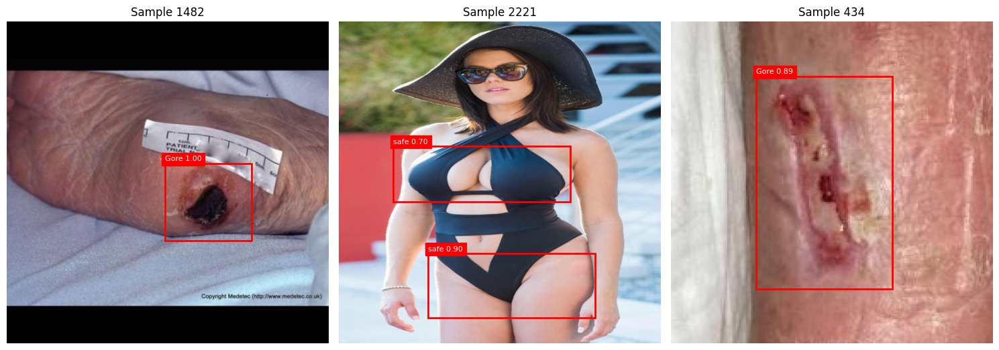

In [19]:
# --- Fix for post-training UnpicklingError (recover model + val_dataset) ---
# train_model() finished all 50 epochs and saved checkpoints/best.pth, but crashed
# on its final reload: PyTorch >= 2.6 defaults torch.load(weights_only=True), which
# rejects the NumPy scalar stored in best.pth ('best_map'). The checkpoint is intact,
# so we just reload it here instead of retraining.
import numpy as np
import torch.serialization

# Allowlist the NumPy scalar so future weights_only=True loads (e.g. the resume path
# in the training cell) won't choke on it either.
try:
    torch.serialization.add_safe_globals([np.core.multiarray.scalar])
except Exception:
    pass

# Rebuild val_dataset (the crash happened before train_model() could return it).
val_dataset = YOLODataset(YAML_PATH, split='val', img_size=IMG_SIZE, cache_images=False)

# Rebuild the model and load the best checkpoint. weights_only=False is safe here:
# it's our own checkpoint from this run.
model = EfficientDetD0(num_classes=val_dataset.num_classes, img_size=IMG_SIZE)
best_path = os.path.join(CKPT_DIR, 'best.pth')
ckpt = torch.load(best_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.to(DEVICE)
model.eval()
print(f"Recovered model from {best_path} "
      f"(val mAP@50-95: {ckpt.get('best_map', float('nan')):.4f}).")

# Persist the plain state_dict the downstream eval/export cells expect.
torch.save(model.state_dict(), 'efficientdet_d0.pth')
print("Saved efficientdet_d0.pth")

# Reproduce the end-of-training visualization that the crash skipped.
print("\nRunning visualization on validation set samples...")
show_inference_results(model, val_dataset)

In [28]:
import time
import pandas as pd

def yolo_style_evaluation(model, dataset, device, batch_size=4, split_name='Validation'):
    print(f"\n{'='*20} Evaluating {split_name} Set ({len(dataset)} images) {'='*20}")
    model.eval()
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2, collate_fn=collate_fn)

    total_inference_time = 0
    total_images = 0
    all_predictions = []
    all_targets = []
    label_counts = {name: 0 for name in dataset.class_names}

    start_wall_time = time.time()

    for images, targets in tqdm(dataloader, desc=f'Evaluating {split_name}'):
        images = torch.stack(images).to(device)
        batch_count = len(images)
        total_images += batch_count

        t_start = time.time()
        with torch.no_grad():
            class_preds, box_preds, anchors = model(images)
            anchors = anchors.to(device)
            for i in range(batch_count):
                scores = torch.sigmoid(class_preds[i])
                max_scores, pred_labels = scores.max(dim=1)
                pred_boxes = decode_boxes(box_preds[i], anchors)
                keep_boxes, keep_scores, keep_labels = multiclass_nms(
                    pred_boxes, max_scores, pred_labels,
                    iou_threshold=0.5, score_threshold=0.05
                )
                all_predictions.append({
                    'boxes': keep_boxes.cpu(),
                    'scores': keep_scores.cpu(),
                    'labels': keep_labels.cpu()
                })
        t_end = time.time()
        total_inference_time += (t_end - t_start)

        for t in targets:
            labels = t['labels'].cpu()
            all_targets.append({'boxes': t['boxes'].cpu(), 'labels': labels})
            for l in labels:
                label_counts[dataset.class_names[l.item()]] += 1

    total_wall_time = time.time() - start_wall_time
    metrics = calculate_metrics(all_predictions, all_targets, num_classes=dataset.num_classes)

    # Metrics: Latency, Samples/Sec (Throughput)
    avg_latency_ms = (total_inference_time / total_images) * 1000
    inference_sps = total_images / total_inference_time # Samples per second
    total_sps = total_images / total_wall_time

    # Add performance metrics to the dict
    metrics['performance'] = {
        'latency_ms': avg_latency_ms,
        'inference_sps': inference_sps,
        'total_sps': total_sps
    }

    print(f"\n--- {split_name} Performance Metrics ---")
    print(f"Latency (Avg):        {avg_latency_ms:.2f} ms/img")
    print(f"Inference Throughput: {inference_sps:.2f} samples/sec")
    print(f"Overall Throughput:   {total_sps:.2f} samples/sec (w/ dataloading)")

    print(f"\n--- {split_name} Accuracy Metrics ---")
    # YOLO-style header: Class | Images | Labels | P | R | mAP@.5 | mAP@.5:.95
    print(f"{'Class':<15} {'Images':<10} {'Labels':<10} {'P':<10} {'R':<10} {'mAP@.5':<10} {'mAP@.5:.95':<10}")
    print("-" * 95)
    for idx, name in enumerate(dataset.class_names):
        lc = label_counts.get(name, 0)
        # calculate_metrics keys per-class results by integer class index, not name.
        if idx in metrics and isinstance(metrics[idx], dict):
            m = metrics[idx]
            print(f"{name:<15} {total_images:<10} {lc:<10} {m['precision']:.3f}      {m['recall']:.3f}      {m['ap50']:.3f}      {m['ap50_95']:.3f}")
        elif lc > 0:
             print(f"{name:<15} {total_images:<10} {lc:<10} {'0.000':<10} {'0.000':<10} {'0.000':<10} {'0.000':<10}")

    print("-" * 95)
    ov = metrics['overall']
    print(f"{'OVERALL':<15} {total_images:<10} {sum(label_counts.values()):<10} {ov['precision']:.3f}      {ov['recall']:.3f}      {ov['ap50']:.3f}      {ov['ap50_95']:.3f}")

    return metrics

def run_full_evaluation():
    val_metrics = None
    test_metrics = None

    # Evaluate Validation Set
    if 'val_dataset' in globals():
        val_metrics = yolo_style_evaluation(model, val_dataset, DEVICE, BATCH_SIZE, split_name='Validation')

    # Evaluate Test Set (if available)
    try:
        print("\nChecking for Test set...")
        test_dataset = YOLODataset(YAML_PATH, split='test', img_size=IMG_SIZE)
        if len(test_dataset) > 0:
            test_metrics = yolo_style_evaluation(model, test_dataset, DEVICE, BATCH_SIZE, split_name='Test')
        else:
            print("Test dataset is empty.")
    except Exception as e:
        print(f"Could not load Test dataset: {e}\n(This is expected if no 'test' split exists in data.yaml)")

    return val_metrics, test_metrics

if 'model' in globals():
    val_metrics, test_metrics = run_full_evaluation()


==================== Evaluating Validation Set (2416 images) ====================


Evaluating Validation: 100%|██████████| 76/76 [00:20<00:00,  3.75it/s]



--- Validation Performance Metrics ---
Latency (Avg):        3.37 ms/img
Inference Throughput: 297.17 samples/sec
Overall Throughput:   119.05 samples/sec (w/ dataloading)

--- Validation Accuracy Metrics ---
Class           Images     Labels     P          R          mAP@.5     mAP@.5:.95
-----------------------------------------------------------------------------------------------
Gore            2416       1348       0.878      0.768      0.832      0.426
nsfw            2416       1830       0.688      0.574      0.560      0.217
safe            2416       776        0.651      0.673      0.584      0.214
-----------------------------------------------------------------------------------------------
OVERALL         2416       3954       0.739      0.671      0.659      0.286

Checking for Test set...
Test dataset is empty.


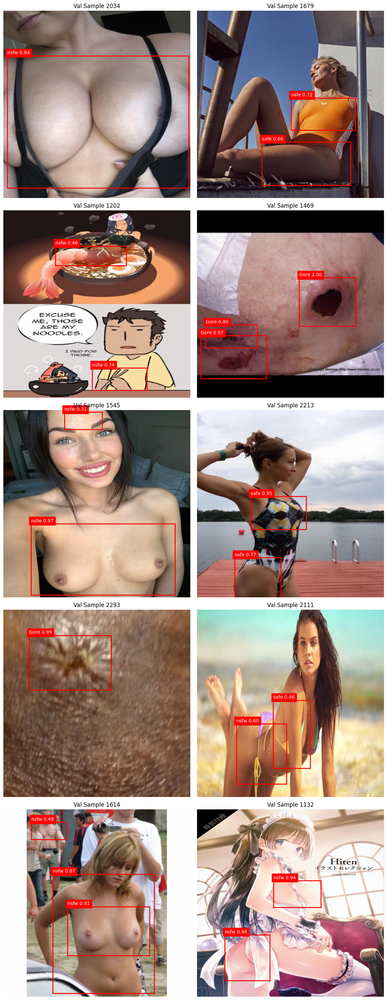

In [29]:
import matplotlib.pyplot as plt
import random

def show_validation_samples(model, dataset, num_samples=10, cols=2):
    model.eval()
    samples_len = len(dataset)
    if samples_len < num_samples:
        num_samples = samples_len

    # Calculate grid dimensions
    rows = (num_samples + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 6))
    axes = axes.flatten()

    # Get random indices
    indices = random.sample(range(samples_len), num_samples)

    for i, idx in enumerate(indices):
        img_tensor, target = dataset[idx]

        # Inference
        with torch.no_grad():
            img_batch = img_tensor.unsqueeze(0).to(DEVICE)
            class_preds, box_preds, anchors = model(img_batch)
            scores = torch.sigmoid(class_preds[0])
            max_scores, pred_labels = scores.max(dim=1)
            pred_boxes = decode_boxes(box_preds[0], anchors.to(DEVICE))
            keep_boxes, keep_scores, keep_labels = multiclass_nms(
                pred_boxes, max_scores, pred_labels, score_threshold=0.3
            )

        # Image processing for display
        img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
        img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_np = np.clip(img_np, 0, 1)

        ax = axes[i]
        ax.imshow(img_np)

        # Draw predictions
        for box, label, score in zip(keep_boxes.cpu(), keep_labels.cpu(), keep_scores.cpu()):
            x1, y1, x2, y2 = box
            w, h = x2 - x1, y2 - y1
            rect = plt.Rectangle((x1, y1), w, h, fill=False, color='red', linewidth=2)
            ax.add_patch(rect)
            label_text = f"{dataset.class_names[label]} {score:.2f}"
            ax.text(x1, y1-5, label_text, color='white', backgroundcolor='red', fontsize=10)

        ax.set_title(f"Val Sample {idx}")
        ax.axis('off')

    # Hide unused subplots
    for j in range(num_samples, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

if 'model' in globals() and 'val_dataset' in globals():
    show_validation_samples(model, val_dataset, num_samples=10, cols=2)

Generating Confusion Matrix...


Computing CM: 100%|██████████| 604/604 [00:46<00:00, 13.00it/s]


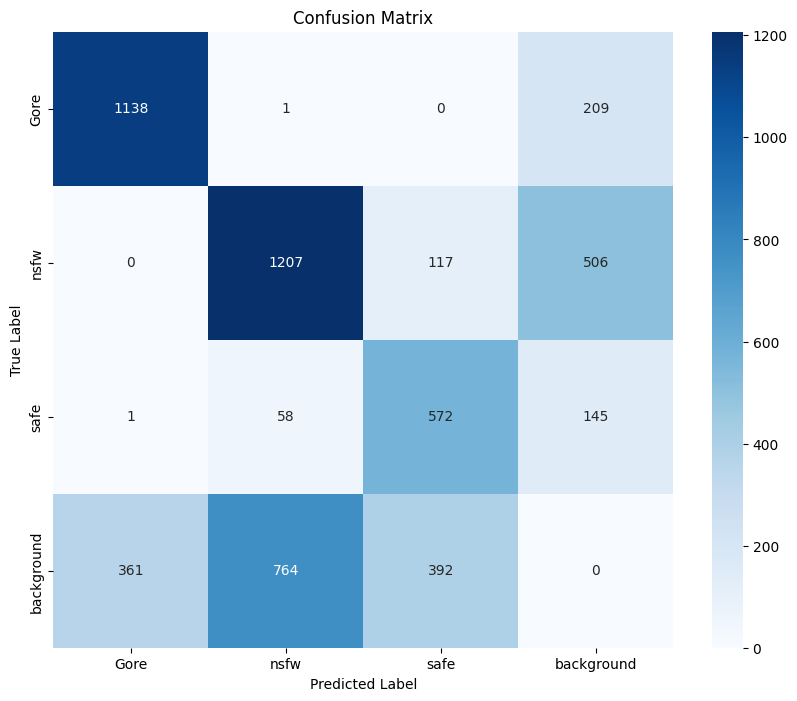

In [30]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, dataset, device, conf_threshold=0.3, iou_threshold=0.5):
    print("Generating Confusion Matrix...")
    model.eval()

    num_classes = dataset.num_classes
    # Matrix: Rows = True Label, Cols = Pred Label
    # Dimensions: (num_classes + 1) x (num_classes + 1)
    # Last index is 'Background'
    cm = np.zeros((num_classes + 1, num_classes + 1), dtype=int)

    dataloader = DataLoader(dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)

    for images, targets in tqdm(dataloader, desc='Computing CM'):
        images = torch.stack(images).to(device)

        with torch.no_grad():
            class_preds, box_preds, anchors = model(images)
            anchors = anchors.to(device)

            for i in range(len(images)):
                # Get Predictions
                scores = torch.sigmoid(class_preds[i])
                max_scores, pred_labels = scores.max(dim=1)
                pred_boxes = decode_boxes(box_preds[i], anchors)

                keep_boxes, keep_scores, keep_labels = multiclass_nms(
                    pred_boxes, max_scores, pred_labels,
                    score_threshold=conf_threshold,
                    iou_threshold=iou_threshold
                )

                # Get Targets
                gt_boxes = targets[i]['boxes'].to(device)
                gt_labels = targets[i]['labels'].to(device)

                if len(keep_boxes) == 0 and len(gt_boxes) == 0:
                    continue

                if len(keep_boxes) == 0:
                    for lbl in gt_labels:
                        cm[lbl.item(), num_classes] += 1 # FN
                    continue

                if len(gt_boxes) == 0:
                    for lbl in keep_labels:
                        cm[num_classes, lbl.item()] += 1 # FP
                    continue

                # Matching
                ious = box_iou(keep_boxes, gt_boxes) # (N_pred, N_gt)

                matched_gt = set()
                matched_pred = set()

                if ious.numel() > 0:
                    # Flatten and sort to do greedy matching
                    vals, indices = torch.sort(ious.flatten(), descending=True)

                    for val, idx in zip(vals, indices):
                        if val < iou_threshold:
                            break

                        p_idx = (idx // ious.shape[1]).item()
                        g_idx = (idx % ious.shape[1]).item()

                        if p_idx not in matched_pred and g_idx not in matched_gt:
                            # Match found
                            gt_cls = gt_labels[g_idx].item()
                            pred_cls = keep_labels[p_idx].item()
                            cm[gt_cls, pred_cls] += 1
                            matched_pred.add(p_idx)
                            matched_gt.add(g_idx)

                # Handle unmatched Preds (False Positives) -> GT=Background
                for p_idx in range(len(keep_boxes)):
                    if p_idx not in matched_pred:
                        pred_cls = keep_labels[p_idx].item()
                        cm[num_classes, pred_cls] += 1

                # Handle unmatched GTs (False Negatives) -> Pred=Background
                for g_idx in range(len(gt_boxes)):
                    if g_idx not in matched_gt:
                        gt_cls = gt_labels[g_idx].item()
                        cm[gt_cls, num_classes] += 1

    # Plotting
    class_names = dataset.class_names + ['background']

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

    return cm

if 'model' in globals() and 'val_dataset' in globals():
    plot_confusion_matrix(model, val_dataset, DEVICE)

Evaluating Validation:   0%|          | 0/76 [00:00<?, ?it/s]

Created output directory: evaluation_results
Saved model weights to evaluation_results/efficientdet_d0.pth
Running evaluation to save metrics.txt and json files...


Evaluating Validation: 100%|██████████| 76/76 [00:18<00:00,  4.03it/s]


Saved metrics log to evaluation_results/metrics.txt
Saved validation metrics to evaluation_results/val_metrics.json
Generating and saving confusion matrix...
Generating Confusion Matrix...


Computing CM: 100%|██████████| 604/604 [00:46<00:00, 12.99it/s]


Saved plot to evaluation_results/confusion_matrix.png


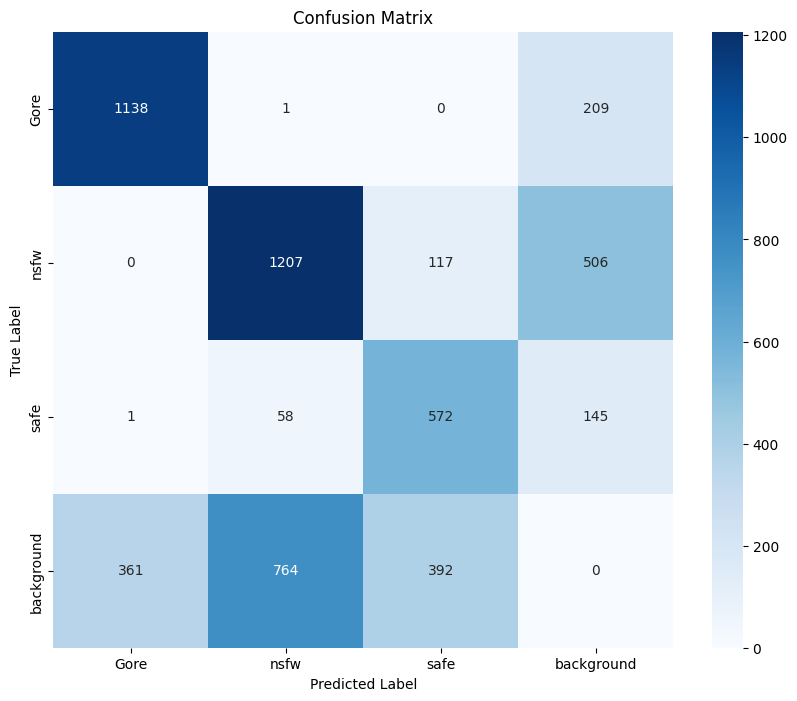

Generating and saving validation samples...
Saved plot to evaluation_results/validation_samples.png


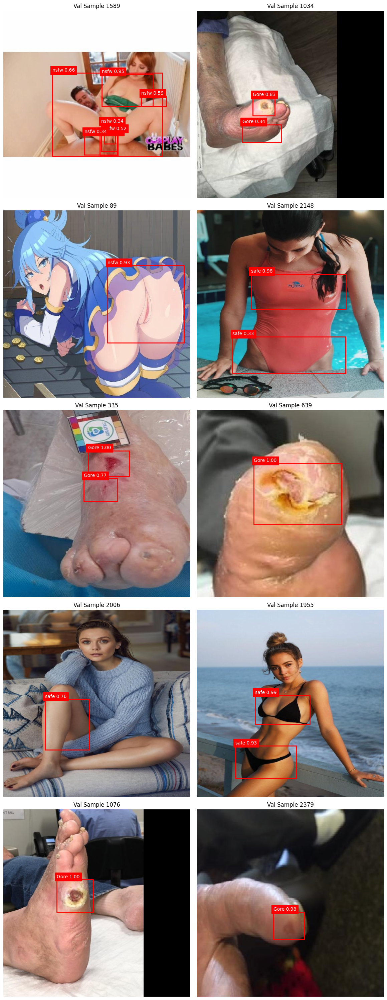

✅ All outputs saved successfully.


In [31]:
import os
import shutil
import json
import numpy as np
from contextlib import redirect_stdout

class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super(NpEncoder, self).default(obj)

# Define output directory
OUTPUT_DIR = 'evaluation_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Created output directory: {OUTPUT_DIR}")

# 1. Save Model Weights
if os.path.exists('efficientdet_d0.pth'):
    dst_path = os.path.join(OUTPUT_DIR, 'efficientdet_d0.pth')
    shutil.copy('efficientdet_d0.pth', dst_path)
    print(f"Saved model weights to {dst_path}")

# 2. Save Evaluation Metrics (Text & JSON)
print("Running evaluation to save metrics.txt and json files...")
metrics_path = os.path.join(OUTPUT_DIR, 'metrics.txt')

with open(metrics_path, 'w') as f:
    with redirect_stdout(f):
        # Run full evaluation (Val + Test)
        val_metrics, test_metrics = run_full_evaluation()

print(f"Saved metrics log to {metrics_path}")

# Save Val Metrics JSON
if val_metrics:
    val_path = os.path.join(OUTPUT_DIR, 'val_metrics.json')
    with open(val_path, 'w') as f:
        json.dump(val_metrics, f, indent=4, cls=NpEncoder)
    print(f"Saved validation metrics to {val_path}")

# Save Test Metrics JSON
if test_metrics:
    test_path = os.path.join(OUTPUT_DIR, 'test_metrics.json')
    with open(test_path, 'w') as f:
        json.dump(test_metrics, f, indent=4, cls=NpEncoder)
    print(f"Saved test metrics to {test_path}")

# Helper to intercept plt.show()
original_show = plt.show

def save_plot_wrapper(filename):
    def wrapper():
        save_path = os.path.join(OUTPUT_DIR, filename)
        plt.savefig(save_path, bbox_inches='tight')
        print(f"Saved plot to {save_path}")
        original_show() # Show in notebook as well
    return wrapper

# 3. Save Confusion Matrix
print("Generating and saving confusion matrix...")
plt.show = save_plot_wrapper('confusion_matrix.png')
plot_confusion_matrix(model, val_dataset, DEVICE)

# 4. Save Validation Samples
print("Generating and saving validation samples...")
plt.show = save_plot_wrapper('validation_samples.png')
show_validation_samples(model, val_dataset, num_samples=10, cols=2)

# Restore original plt.show
plt.show = original_show

print("✅ All outputs saved successfully.")

In [32]:
!pip install onnxscript optimum[onnxruntime]

In [33]:
import torch.onnx

# Define output path
ONNX_PATH = os.path.join(OUTPUT_DIR, 'efficientdet_d0.onnx')

print("Exporting model to ONNX...")

# 1. Set model to evaluation mode
model.eval()

# 2. Create dummy input (Batch Size: 1, Channels: 3, Height: IMG_SIZE, Width: IMG_SIZE)
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)

# 3. Export
try:
    torch.onnx.export(
        model,
        dummy_input,
        ONNX_PATH,
        export_params=True,        # Store the trained parameter weights inside the model file
        opset_version=12,          # The ONNX version to export the model to
        do_constant_folding=True,  # Whether to execute constant folding for optimization
        input_names=['input'],     # The model's input names
        output_names=['class_preds', 'box_preds', 'anchors'], # The model's output names
        dynamic_axes={
            'input': {0: 'batch_size'},
            'class_preds': {0: 'batch_size'},
            'box_preds': {0: 'batch_size'},
            'anchors': {0: 'batch_size'} # Anchors might be static depending on implementation, but let's try dynamic
        }
    )
    print(f"✅ Model successfully exported to {ONNX_PATH}")
except Exception as e:
    print(f"❌ Export failed: {e}")

# 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
W0716 02:40:04.034000 2499 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 12 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


Exporting model to ONNX...
[torch.onnx] Obtain model graph for `EfficientDetD0([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientDetD0([...]` with `torch.export.export(..., strict=False)`... ❌
[torch.onnx] Obtain model graph for `EfficientDetD0([...]` with `torch.export.export(..., strict=True)`...
[torch.onnx] Obtain model graph for `EfficientDetD0([...]` with `torch.export.export(..., strict=True)`... ✅
[torch.onnx] Run decompositions...


`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...


[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /project/onnx/version_converter/adapters/axes_input_to_attribute.h:56: adapt: Assertion `node-

[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
✅ Model successfully exported to evaluation_results/efficientdet_d0.onnx


In [34]:
!zip -r efficientdet_metrics.zip evaluation_results/

updating: evaluation_results/ (stored 0%)
updating: evaluation_results/confusion_matrix.png (deflated 14%)
updating: evaluation_results/efficientdet_d0.onnx (deflated 93%)
updating: evaluation_results/efficientdet_d0.pth (deflated 8%)
updating: evaluation_results/val_metrics.json (deflated 63%)
updating: evaluation_results/validation_samples.png (deflated 0%)
updating: evaluation_results/metrics.txt (deflated 62%)
updating: evaluation_results/efficientdet_d0.onnx.data (deflated 9%)


In [35]:
from google.colab import files
files.download('efficientdet_metrics.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>